<a href="https://colab.research.google.com/github/alaaguedda/Hybrid-Texture-Intelligence/blob/main/hybrid_texture_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# INSTALL REQUIRED LIBRARIES
# ============================================

!pip install -q kaggle scikit-image opencv-python seaborn

# ============================================
# IMPORT LIBRARIES
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam

# ============================================
# KAGGLE AUTHENTICATION
# ============================================

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# ============================================
# DOWNLOAD DATASETS
# ============================================

# Example Kaggle datasets (replace if needed)

!kaggle datasets download -d jmexpert/describable-textures-dataset-dtd -p data --unzip
# Example placeholder if texture datasets differ
# !kaggle datasets download -d your_dataset_name --unzip -p data

# ============================================
# CHECK DATA STRUCTURE
# ============================================

DATA_DIR = "data"

for root, dirs, files in os.walk(DATA_DIR):
    print(root, len(files))

Dataset URL: https://www.kaggle.com/datasets/jmexpert/describable-textures-dataset-dtd
License(s): unknown
 99% 1.16G/1.17G [00:05<00:00, 191MB/s]
100% 1.17G/1.17G [00:05<00:00, 212MB/s]
data 0
data/dtd-r1.0.1 0
data/dtd-r1.0.1/dtd 0
data/dtd-r1.0.1/dtd/imdb 1
data/dtd-r1.0.1/dtd/images 0
data/dtd-r1.0.1/dtd/images/grid 120
data/dtd-r1.0.1/dtd/images/chequered 120
data/dtd-r1.0.1/dtd/images/grooved 120
data/dtd-r1.0.1/dtd/images/gauzy 120
data/dtd-r1.0.1/dtd/images/interlaced 120
data/dtd-r1.0.1/dtd/images/lacelike 120
data/dtd-r1.0.1/dtd/images/sprinkled 120
data/dtd-r1.0.1/dtd/images/swirly 120
data/dtd-r1.0.1/dtd/images/bubbly 120
data/dtd-r1.0.1/dtd/images/paisley 120
data/dtd-r1.0.1/dtd/images/cracked 120
data/dtd-r1.0.1/dtd/images/veined 120
data/dtd-r1.0.1/dtd/images/blotchy 120
data/dtd-r1.0.1/dtd/images/stained 120
data/dtd-r1.0.1/dtd/images/stratified 120
data/dtd-r1.0.1/dtd/images/honeycombed 120
data/dtd-r1.0.1/dtd/images/scaly 120
data/dtd-r1.0.1/dtd/images/matted 120
data

In [ ]:
# ============================================
# LOAD DATASET CORRECTLY (DTD DATASET)
# ============================================

IMG_SIZE = 128

DATASET_PATH = "data/dtd/images"

def preprocess_image(path):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Histogram equalization
    img = cv2.equalizeHist(img)

    # Gaussian filtering
    img = cv2.GaussianBlur(img, (3,3), 0)

    # Normalize
    img = img / 255.0

    return img


images = []
labels = []
class_names = []

# Get class folders
for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    class_names.append(class_name)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = preprocess_image(img_path)

        if img is not None:
            images.append(img)
            labels.append(class_names.index(class_name))


X = np.array(images)
y = np.array(labels)

print("Dataset shape:", X.shape)
print("Number of classes:", len(class_names))
print("Classes:", class_names[:10])

Dataset shape: (5640, 128, 128)
Number of classes: 47
Classes: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline']


In [ ]:
# ============================================
# FEATURE EXTRACTION
# GLCM + LBP
# ============================================

def extract_features(image):

    features = []

    # Convert to uint8 for texture features
    img = (image * 255).astype(np.uint8)

    # -------- GLCM FEATURES --------
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    features.append(graycoprops(glcm, 'contrast')[0,0])
    features.append(graycoprops(glcm, 'dissimilarity')[0,0])
    features.append(graycoprops(glcm, 'homogeneity')[0,0])
    features.append(graycoprops(glcm, 'energy')[0,0])
    features.append(graycoprops(glcm, 'correlation')[0,0])

    # -------- LBP FEATURES --------
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    (hist, _) = np.histogram(lbp.ravel(),
                             bins=np.arange(0, 10),
                             range=(0, 9))

    hist = hist.astype("float")
    hist /= hist.sum()

    features.extend(hist)

    return np.array(features)


# Extract features for all images

X_features = np.array([extract_features(img) for img in X])

print("Feature vector size:", X_features.shape)

Feature vector size: (5640, 14)


SVM Accuracy: 0.03900709219858156
KNN Accuracy: 0.04698581560283688
RandomForest Accuracy: 0.26595744680851063


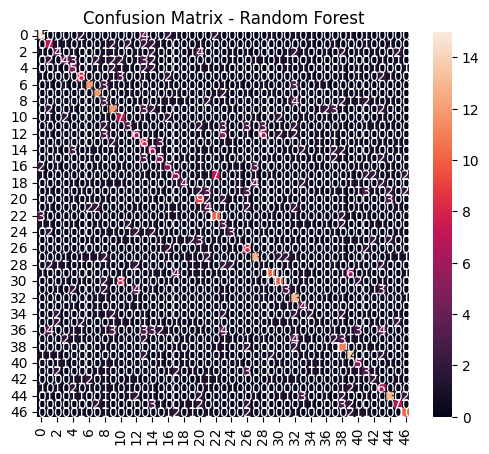

In [ ]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

# ============================================
# SVM
# ============================================

svm = SVC(probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


# ============================================
# KNN
# ============================================

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))


# ============================================
# RANDOM FOREST
# ============================================

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, rf_pred))


# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
# ============================================
# PREPARE DATA FOR CNN
# ============================================

X_dl = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_dl, y, test_size=0.2, random_state=42
)

# ============================================
# DATA AUGMENTATION
# ============================================

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# ============================================
# CNN MODEL
# ============================================

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(class_names),activation='softmax')

])

model.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# TRAIN MODEL
# ============================================

history = model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=10,
    validation_data=(X_test,y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,310,127 (12.63 MB)

 Trainable params: 3,310,127 (12.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.0202 - loss: 3.8535 - val_accuracy: 0.0195 - val_loss: 3.8501
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.0235 - loss: 3.8460 - val_accuracy: 0.0266 - val_loss: 3.8453
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.0239 - loss: 3.8383 - val_accuracy: 0.0177 - val_loss: 3.8337
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.0324 - loss: 3.8204 - val_accuracy: 0.0293 - val_loss: 3.8141
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.0379 - loss: 3.7901 - val_accuracy: 0.0337 - val_loss: 3.8174
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.0448 - loss: 3.7571 - val_accuracy: 0.0363 - val_loss: 3.7739
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.0581 - loss: 3.7051 - val_accuracy: 0.0638 - val_loss: 3.7086
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.0734 - loss: 3.6575 - val_accu

In [ ]:
# ============================================
# RESNET REQUIRES 3 CHANNELS
# ============================================

X_rgb = np.repeat(X_dl,3,axis=-1)

X_train, X_test, y_train, y_test = train_test_split(
    X_rgb, y, test_size=0.2, random_state=42
)

# ============================================
# LOAD PRETRAINED MODEL
# ============================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128,activation='relu')(x)
output = layers.Dense(len(class_names),activation='softmax')(x)

model_tl = tf.keras.Model(base_model.input, output)

model_tl.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

# ============================================
# TRAIN
# ============================================

model_tl.fit(
    X_train, y_train,
    validation_data=(X_test,y_test),
    epochs=5,
    batch_size=32
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,856,047 (91.00 MB)

 Trainable params: 268,335 (1.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.0244 - loss: 3.8936 - val_accuracy: 0.0222 - val_loss: 3.8604
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.0317 - loss: 3.8367 - val_accuracy: 0.0372 - val_loss: 3.8349
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.0565 - loss: 3.8115 - val_accuracy: 0.0488 - val_loss: 3.8156
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.0641 - loss: 3.7894 - val_accuracy: 0.0585 - val_loss: 3.7961
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.0705 - loss: 3.7665 - val_accuracy: 0.0709 - val_loss: 3.7762


36/36 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step
              precision    recall  f1-score   support

           0       0.31      0.32      0.32        31
           1       0.00      0.00      0.00        25
           2       0.00      0.00      0.00        29
           3       0.00      0.00      0.00        30
           4       0.00      0.00      0.00        24
           5       0.10      0.68      0.18        22
           6       0.00      0.00      0.00        29
           7       0.00      0.00      0.00        21
           8       0.00      0.00      0.00        24
           9       0.00      0.00      0.00        31
          10       0.08      0.05      0.06        20
          11       0.00      0.00      0.00        25
          12       0.00      0.00      0.00        31
          13       0.00      0.00      0.00        21
          14       0.00      0.00      0.00        28
          15       0.03      0.43      0.06        21
          16       0.12      0.05      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


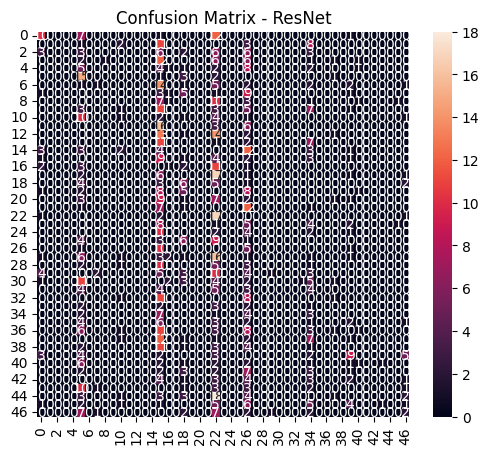

In [ ]:
# ============================================
# FINAL EVALUATION
# ============================================

pred = model_tl.predict(X_test)
pred_classes = np.argmax(pred,axis=1)

print(classification_report(y_test,pred_classes))

cm = confusion_matrix(y_test,pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix - ResNet")
plt.show()